# Прогон только моделей

In [1]:
import numpy as np
import pandas as pd
import holidays
import matplotlib.pyplot as plt
import seaborn as sns

## Подготовка данных

In [2]:
file_path = 'data/telecom_square_5200_cleaned.csv'
df_ts = pd.read_csv(file_path, index_col=False)
try:
    df_ts = df_ts.drop(columns='Unnamed: 0')
except:
    pass
# Данные под Nixtla
df_ts['ds'] = pd.to_datetime(df_ts['ds'])
df_ts['y'] = df_ts['y'].astype(float)
df_ts['unique_id'] = df_ts['unique_id'].astype(int)

# Дополнение признаками
df_ts.set_index('ds', inplace=True)
df_ts['hour'] = df_ts.index.hour
df_ts['day_of_week'] = df_ts.index.dayofweek
df_ts['day'] = df_ts.index.day
df_ts['week'] = df_ts.index.isocalendar().week
df_ts['month'] = df_ts.index.month
df_ts['is_weekend'] = df_ts['day_of_week'].isin([5, 6]).astype(int)
it_holidays = holidays.IT(years=[2013, 2014])
df_ts['is_holiday'] = df_ts.index.to_series().dt.date.apply(lambda x: x in it_holidays).astype(int)

df_ts = df_ts.reset_index()

start_date = '2013-11-04'
mid_date = '2013-12-10'
end_date = pd.to_datetime(mid_date) + pd.Timedelta(days=1)

df_ts = df_ts[(start_date <= df_ts['ds']) & (df_ts['ds'] < end_date)].reset_index(drop=True)

df_ts.head()

,ds,y,unique_id,hour,day_of_week,day,week,month,is_weekend,is_holiday
0,2013-11-04 00:00:00,646.695936,5200,0,0,4,45,11,0,0
1,2013-11-04 00:10:00,682.688973,5200,0,0,4,45,11,0,0
2,2013-11-04 00:20:00,640.407509,5200,0,0,4,45,11,0,0
3,2013-11-04 00:30:00,842.972689,5200,0,0,4,45,11,0,0
4,2013-11-04 00:40:00,661.532571,5200,0,0,4,45,11,0,0


## Отчистка выбросов

→ Выявление аномалий с помощью Isolation Forest
Выявлено выбросов: 54 из 5328


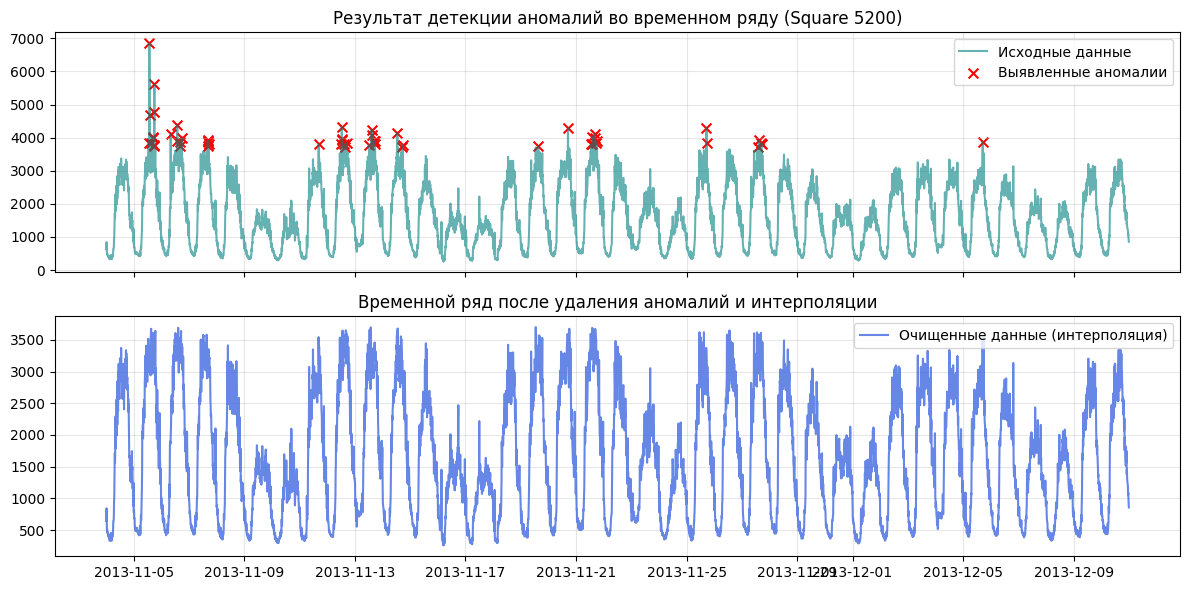

,ds,y,unique_id,hour,day_of_week,day,week,month,is_weekend,is_holiday
0,2013-11-04 00:00:00,646.695936,5200,0,0,4,45,11,0,0
1,2013-11-04 00:10:00,682.688973,5200,0,0,4,45,11,0,0
2,2013-11-04 00:20:00,640.407509,5200,0,0,4,45,11,0,0
3,2013-11-04 00:30:00,842.972689,5200,0,0,4,45,11,0,0
4,2013-11-04 00:40:00,661.532571,5200,0,0,4,45,11,0,0


In [3]:
from sklearn.ensemble import IsolationForest
print("→ Выявление аномалий с помощью Isolation Forest")

# Для детекции аномалий используем целевую переменную
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df_ts['anomaly'] = iso_forest.fit_predict(df_ts[['y']])

# Аномалии помечаются как -1
anomalies = df_ts[df_ts['anomaly'] == -1]
print(f"Выявлено выбросов: {len(anomalies)} из {len(df_ts)}")

# Визуализация аномалий
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df_ts['ds'], df_ts['y'], color='teal', alpha=0.6, label='Исходные данные')
axes[0].scatter(anomalies['ds'], anomalies['y'], color='red', marker='x', s=50, label='Выявленные аномалии')
axes[0].set_title('Результат детекции аномалий во временном ряду (Square 5200)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Очистка: Заменяем аномальные выбросы линейной интерполяцией, чтобы не сбивать ML-модели
df_ts = df_ts.copy()
df_ts.loc[df_ts['anomaly'] == -1, 'y'] = np.nan
df_ts['y'] = df_ts['y'].interpolate(method='linear')

axes[1].plot(df_ts['ds'], df_ts['y'], color='royalblue', alpha=0.8, label='Очищенные данные (интерполяция)')
axes[1].set_title('Временной ряд после удаления аномалий и интерполяции')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

df_ts = df_ts.drop(columns='anomaly')

# Оптимизация расстояния между графиками и вывод
plt.tight_layout()
plt.show()

df_ts.head()

## Модели

In [26]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA, 
    AutoETS, 
    AutoTheta
)
from utilsforecast.losses import mae, mse, rmse
from utilsforecast.evaluation import evaluate

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.utils import PredictionIntervals
from window_ops.rolling import rolling_mean, rolling_std
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

SEASON = 144 # 1 сутки
horizon = SEASON
np.random.seed(1)
rnd_id = 1

# Разделение очищенных данных на Train/Test
df_train = df_ts[(start_date <= df_ts['ds']) & (df_ts['ds'] < mid_date)].copy()
df_test = df_ts[(mid_date <= df_ts['ds']) & (df_ts['ds'] < end_date)].copy()

X_df_list = df_test[[col for col in df_test.columns if col != 'y']]

### Статистические модели

In [5]:
models = [
    AutoARIMA(season_length=SEASON, approximation=True),  # approximation=True существенно ускоряет расчет
    AutoETS(season_length=SEASON, model='ZMN'),        # ZMN автоматически подбирает тип тренда/сезона
    AutoTheta(season_length=SEASON)
]

models_sf = ['AutoARIMA', 'AutoETS', 'AutoTheta']

# Создаем объект StatsForecast
sf = StatsForecast(
    models=models,
    freq='10min',  # Частота данных — 10 минут
    n_jobs=-1      # Использовать все доступные ядра процессора
)

# Обучение
print('→ Обучение cтатистических моделей через StatsForecast')
sf.fit(df_train)
print('Done')

Обучнение
Done


In [22]:
df_sf_pred = sf.predict(h=horizon, X_df=X_df_list)

df_sf_pred.head()

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta
0,5200,2013-12-10 00:00:00,778.223511,855.535400,766.501282
1,5200,2013-12-10 00:10:00,725.451050,836.215759,708.812622
2,5200,2013-12-10 00:20:00,649.938721,818.633057,681.259888
3,5200,2013-12-10 00:30:00,652.774231,802.606506,677.545227
4,5200,2013-12-10 00:40:00,623.588623,787.977539,629.386658


### Модели машинного обучения

In [8]:
models_mlf = ['LightGBM', 'XGBoost']

# Инициализируем MLForecast
models = {
        'LightGBM': LGBMRegressor(
            random_state=rnd_id,
            n_estimators=150,
            learning_rate=0.05
            ),
        'XGBoost': XGBRegressor(
            random_state=rnd_id,
            n_estimators=150,
            learning_rate=0.05
            )
    }

date_features = [
    'hour',           # час дня (0-23)
    'day_of_week',    # день недели (0-6)
    'month',          # месяц (1-12)
    'day',            # день месяца
    'week',           # неделя года
    'is_holiday'
]

lags = [
    1, 2, 3,                            # ближайшие лаги
    SEASON - 1, SEASON, SEASON + 1,     # суточная сезонность
    SEASON * 2,                         # двухсуточная сезонность (!?!??!?)
]

lag_transforms={
        1: [(rolling_mean, 6), (rolling_std, 6)], # Статистика за последний час (6 интервалов по 10 мин)
        SEASON: [(rolling_mean, SEASON)]          # Статистика за прошлые сутки
    }

mlf = MLForecast(
    models=models,
    freq='10min',
    lags=lags,
    lag_transforms=lag_transforms,
    # date_features=date_features,
    num_threads=-1
)

# Обучение моделей с автоматической генерацией признаков внутри фреймворка
print("→ Обучение моделей машинного обучения через MLForecast")
mlf.fit(
    df_train,
    static_features=[],
    prediction_intervals = PredictionIntervals(n_windows=5, h=horizon)  # Для Дов.Интервала
)

→ Обучение моделей машинного обучения через MLForecast
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000307 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2622
[LightGBM] [Info] Number of data points in the train set: 4176, number of used features: 16
[LightGBM] [Info] Start training from score 1660.727034
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2626
[LightGBM] [Info] Number of data points in the train set: 4896, number of used features: 17
[LightGBM] [Info] Start training from score 1634.655594


MLForecast(models=[LightGBM, XGBoost], freq=10min, lag_features=['lag1', 'lag2', 'lag3', 'lag143', 'lag144', 'lag145', 'lag288', 'rolling_mean_lag1_window_size6', 'rolling_std_lag1_window_size6', 'rolling_mean_lag144_window_size144'], date_features=[], num_threads=12)

In [23]:
df_mlf_pred = mlf.predict(horizon, X_df=X_df_list)

df_mlf_pred.head()

,unique_id,ds,LightGBM,XGBoost
0,5200,2013-12-10 00:00:00,786.973074,757.926331
1,5200,2013-12-10 00:10:00,762.984663,745.217896
2,5200,2013-12-10 00:20:00,738.883385,736.658264
3,5200,2013-12-10 00:30:00,727.390811,708.395264
4,5200,2013-12-10 00:40:00,723.066986,666.380859


In [27]:
df_eval = df_test.copy()

df_eval = df_eval.merge(df_sf_pred, on=['unique_id', 'ds'])
df_eval = df_eval.merge(df_mlf_pred, on=['unique_id', 'ds'])

df_eval.head()

,ds,y,unique_id,hour,day_of_week,day,week,month,is_weekend,is_holiday,AutoARIMA,AutoETS,AutoTheta,LightGBM,XGBoost
0,2013-12-10 00:00:00,900.766381,5200,0,1,10,50,12,0,0,778.223511,855.535400,766.501282,786.973074,757.926331
1,2013-12-10 00:10:00,735.569373,5200,0,1,10,50,12,0,0,725.451050,836.215759,708.812622,762.984663,745.217896
2,2013-12-10 00:20:00,911.667448,5200,0,1,10,50,12,0,0,649.938721,818.633057,681.259888,738.883385,736.658264
3,2013-12-10 00:30:00,756.652489,5200,0,1,10,50,12,0,0,652.774231,802.606506,677.545227,727.390811,708.395264
4,2013-12-10 00:40:00,722.218302,5200,0,1,10,50,12,0,0,623.588623,787.977539,629.386658,723.066986,666.380859


### Графики предсказаний

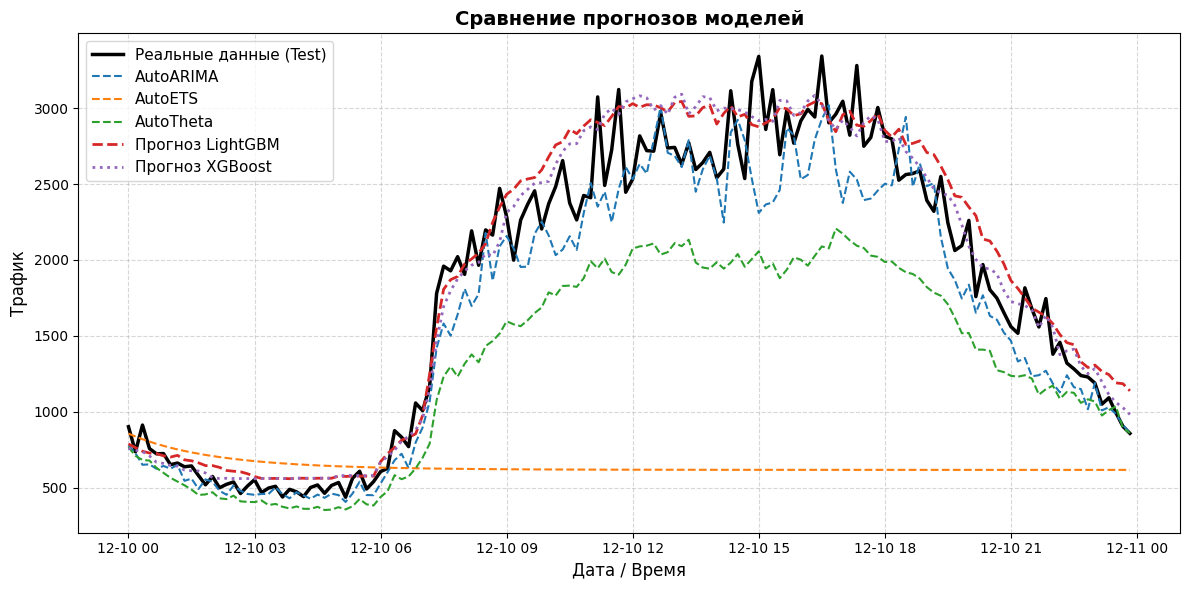

In [28]:
df_plot = df_eval.sort_values('ds').head(144)

plt.figure(figsize=(12, 6))
# Реальные данные
plt.plot(df_plot['ds'], df_plot['y'], label='Реальные данные (Test)', color='black', linewidth=2.5)

plt.plot(df_plot['ds'], df_plot['AutoARIMA'], label='AutoARIMA', linestyle='--')
plt.plot(df_plot['ds'], df_plot['AutoETS'], label='AutoETS', linestyle='--')
plt.plot(df_plot['ds'], df_plot['AutoTheta'], label='AutoTheta', linestyle='--')
plt.plot(df_plot['ds'], df_plot['LightGBM'], label='Прогноз LightGBM', linestyle='--', linewidth=2)
plt.plot(df_plot['ds'], df_plot['XGBoost'], label='Прогноз XGBoost', linestyle=':', linewidth=2)

plt.title("Сравнение прогнозов моделей", fontsize=14, fontweight='bold')
plt.xlabel("Дата / Время", fontsize=12)
plt.ylabel("Трафик", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Метрики

In [30]:
from utilsforecast.losses import mae, rmse
from utilsforecast.evaluation import evaluate

print("→ Метрики точности ML-моделей")
learn_metrics = evaluate(
    df_eval,
    metrics=[mae, mse, rmse],
    models=models_sf+models_mlf
)
display(learn_metrics)

→ Метрики точности ML-моделей


,unique_id,metric,AutoARIMA,AutoETS,AutoTheta,LightGBM,XGBoost
0,5200,mae,197.954372,1.232920e+03,487.437732,176.047992,155.711793
1,5200,mse,76327.209349,2.287415e+06,346767.450101,50160.653852,42677.707275
2,5200,rmse,276.273794,1.512420e+03,588.869638,223.965743,206.585835


### Статисткиа

In [33]:
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

print(f"Статистика для {models_sf+models_mlf}")


print("\n→ Статистический тест Льюнга-Бокса на независимость остатков")
lag_counts = [6, 24]
for chosen_model in models_sf+models_mlf:
    residuals = df_eval['y'] - df_eval[chosen_model]
    lb_test = acorr_ljungbox(residuals, lags=lag_counts, return_df=True)
    print(f"\nРезультаты теста Льюнга-Бокса для {chosen_model}:")
    print(lb_test)
    p_val_key = lb_test['lb_pvalue'].iloc[-1]
    print(f"\np-value на максимальном проверенном лаге ({lag_counts[-1]}): {p_val_key}")
    if p_val_key > 0.05:
        print("ВЫВОД: Остатки являются независимыми (Белый шум). Модель полностью извлекла информацию из структуры ВР.")
    else:
        print("ВЫВОД: В остатках присутствует автокорреляция. Модель упустила часть системной информации (возможно, требуются дополнительные лаги или экзогенные признаки).")
    

Статистика для ['AutoARIMA', 'AutoETS', 'AutoTheta', 'LightGBM', 'XGBoost']

→ Статистический тест Льюнга-Бокса на независимость остатков

Результаты теста Льюнга-Бокса для AutoARIMA:
      lb_stat  lb_pvalue
6   35.375809   0.000004
24  59.409882   0.000077

p-value на максимальном проверенном лаге (24): 7.7347455941211e-05
ВЫВОД: В остатках присутствует автокорреляция. Модель упустила часть системной информации (возможно, требуются дополнительные лаги или экзогенные признаки).

Результаты теста Льюнга-Бокса для AutoETS:
        lb_stat      lb_pvalue
6    776.792833  1.589778e-164
24  2011.642276   0.000000e+00

p-value на максимальном проверенном лаге (24): 0.0
ВЫВОД: В остатках присутствует автокорреляция. Модель упустила часть системной информации (возможно, требуются дополнительные лаги или экзогенные признаки).

Результаты теста Льюнга-Бокса для AutoTheta:
        lb_stat      lb_pvalue
6    506.906701  2.734019e-106
24  1113.871116  5.461435e-220

p-value на максимальном провер

# Сохранение моделей

In [39]:
import os
import joblib

os.makedirs('model', exist_ok=True)

joblib.dump(sf, 'model/AutoARIMA_AutoETS_AutoTheta_models.pkl')
joblib.dump(mlf, 'model/LightGBM_XGBoost_models.pkl')

['model/LightGBM_XGBoost_models.pkl']